# Clase 28 de Septiembre

## Librerias y datos

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
ruta = "contaminantes/contaminantes_2026_nuevo.csv"

df = pd.read_csv(
    ruta,
    skiprows=9,
    low_memory=False
)

df["date"] = pd.to_datetime(df["date"])

display(df.head())

,date,id_station,id_parameter,valor,unit
0,2026-01-01,ACO,CO,NaN,15
1,2026-01-01,ACO,NO,NaN,1
2,2026-01-01,ACO,NO2,NaN,1
3,2026-01-01,ACO,NOX,NaN,1
4,2026-01-01,ACO,O3,NaN,1


## a) Tabla estación-hora y contaminantes 

In [29]:
tabla = df.pivot_table(
    index=["date", "id_station"],
    columns="id_parameter",
    values="valor",
    aggfunc="mean"
).reset_index()

tabla.columns.name = None

display(tabla.head())

,date,id_station,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
0,2026-01-01,AJM,0.74,2.0,26.0,28.0,19.0,67.0,53.0,14.0,28.0
1,2026-01-01,ATI,0.70,2.0,21.0,23.0,18.0,90.0,NaN,NaN,22.0
2,2026-01-01,BJU,1.07,NaN,32.0,NaN,17.0,62.0,41.0,21.0,3.0
3,2026-01-01,CAM,NaN,7.0,44.0,52.0,4.0,57.0,49.0,8.0,25.0
4,2026-01-01,CCA,1.12,1.0,32.0,33.0,13.0,NaN,27.0,NaN,3.0


## b) Covarianza y correlación de CO con NOX

In [30]:
co_nox = tabla[["CO", "NOX"]].dropna()

covarianza = co_nox["CO"].cov(co_nox["NOX"])
correlacion = co_nox["CO"].corr(co_nox["NOX"])

print("Covarianza CO-NOX:", covarianza)
print("Correlación CO-NOX:", correlacion)

Covarianza CO-NOX: 11.586725751371077
Correlación CO-NOX: 0.8656303915950103


In [31]:
print("Matriz de covarianza:")
display(co_nox.cov())

print("Matriz de correlación:")
display(co_nox.corr())

Matriz de covarianza:


,CO,NOX
CO,0.160829,11.586726
NOX,11.586726,1114.018980


Matriz de correlación:


,CO,NOX
CO,1.00000,0.86563
NOX,0.86563,1.00000


## c) Eigenvalores de la matriz de correlación, con y sin faltantes

In [7]:
contaminantes = [
    "CO", "NO", "NO2", "NOX",
    "O3", "PM10", "PM2.5", "PMCO", "SO2"
]

corr_con_faltantes = tabla[contaminantes].corr()

eigen_con_faltantes = np.linalg.eigvalsh(corr_con_faltantes)
eigen_con_faltantes = np.sort(eigen_con_faltantes)[::-1]

print("Matriz de correlación usando pares disponibles:")
display(corr_con_faltantes)

print("Eigenvalores con faltantes:")
print(eigen_con_faltantes)

Matriz de correlación usando pares disponibles:


,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
CO,1.000000,0.754645,0.769117,0.865630,-0.338433,0.421650,0.400146,0.414038,0.158971
NO,0.754645,1.000000,0.483864,0.938831,-0.384038,0.259735,0.192164,0.293456,0.091705
NO2,0.769117,0.483864,1.000000,0.755364,-0.434339,0.399426,0.338749,0.411946,0.160842
NOX,0.865630,0.938831,0.755364,1.000000,-0.453609,0.352691,0.283656,0.378046,0.128637
O3,-0.338433,-0.384038,-0.434339,-0.453609,1.000000,0.077362,0.182075,0.037393,-0.036383
PM10,0.421650,0.259735,0.399426,0.352691,0.077362,1.000000,0.845858,0.840878,0.229808
PM2.5,0.400146,0.192164,0.338749,0.283656,0.182075,0.845858,1.000000,0.437513,0.237217
PMCO,0.414038,0.293456,0.411946,0.378046,0.037393,0.840878,0.437513,1.000000,0.236809
SO2,0.158971,0.091705,0.160842,0.128637,-0.036383,0.229808,0.237217,0.236809,1.000000


Eigenvalores con faltantes:
[ 4.30334433e+00  1.99286324e+00  9.18607074e-01  6.57686418e-01
  5.58406495e-01  4.28956904e-01  1.43673157e-01  7.40368316e-05
 -3.61164851e-03]


In [32]:
tabla_completa = tabla.dropna(subset=contaminantes)

corr_sin_faltantes = tabla_completa[contaminantes].corr()

eigen_sin_faltantes = np.linalg.eigvalsh(corr_sin_faltantes)
eigen_sin_faltantes = np.sort(eigen_sin_faltantes)[::-1]

print("Observaciones completas:", len(tabla_completa))
print("Eigenvalores sin faltantes:")
print(eigen_sin_faltantes)

Observaciones completas: 17955
Eigenvalores sin faltantes:
[4.45566736e+00 1.97826856e+00 9.12215561e-01 6.44520919e-01
 5.52580044e-01 3.34202907e-01 1.22035593e-01 3.77960257e-04
 1.31095637e-04]


In [33]:
comparacion_eigen = pd.DataFrame({
    "Con faltantes": eigen_con_faltantes,
    "Sin faltantes": eigen_sin_faltantes
})

display(comparacion_eigen)

print("Suma con faltantes:", eigen_con_faltantes.sum())
print("Suma sin faltantes:", eigen_sin_faltantes.sum())

,Con faltantes,Sin faltantes
0,4.303344,4.455667
1,1.992863,1.978269
2,0.918607,0.912216
3,0.657686,0.644521
4,0.558406,0.552580
5,0.428957,0.334203
6,0.143673,0.122036
7,0.000074,0.000378
8,-0.003612,0.000131


Suma con faltantes: 9.000000000000004
Suma sin faltantes: 8.999999999999998


## d) PM2.5 contra los demás: R<sup>2</sup> y VIF

In [34]:
y_col = "PM2.5"

X_cols = [
    "CO", "NO", "NO2", "NOX",
    "O3", "PM10", "PMCO", "SO2"
]

datos_modelo = tabla[[y_col] + X_cols].dropna()

X = datos_modelo[X_cols]
y = datos_modelo[y_col]

X_const = sm.add_constant(X)

modelo = sm.OLS(y, X_const).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.325e+06
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:43:35   Log-Likelihood:                -13038.
No. Observations:               17955   AIC:                         2.609e+04
Df Residuals:                   17946   BIC:                         2.616e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0074      0.011      0.649      0.5

In [36]:
print("R²:", modelo.rsquared)
print("R² ajustado:", modelo.rsquared_adj)

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

display(vif.sort_values("VIF", ascending=False))

R²: 0.9983098229638294
R² ajustado: 0.9983090695136851


,Variable,VIF
3,NOX,10284.866044
2,NO2,3475.409537
1,NO,2897.677231
5,PM10,20.447965
0,CO,17.714223
6,PMCO,9.887033
4,O3,2.841925
7,SO2,1.488718


### Modelo de PM2.5 utilizando solamente gases

In [12]:
gases = ["CO", "NO", "NO2", "NOX", "O3", "SO2"]

datos_gases = tabla[["PM2.5"] + gases].dropna()

X_gases = datos_gases[gases]
y_gases = datos_gases["PM2.5"]

X_gases_const = sm.add_constant(X_gases)

modelo_gases = sm.OLS(y_gases, X_gases_const).fit()

print(modelo_gases.summary())

                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     2524.
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:43:07   Log-Likelihood:            -1.2420e+05
No. Observations:               32686   AIC:                         2.484e+05
Df Residuals:                   32679   BIC:                         2.485e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5865      0.184      8.629      0.0

In [13]:
vif_gases = pd.DataFrame({
    "Variable": X_gases.columns,
    "VIF": [
        variance_inflation_factor(X_gases.values, i)
        for i in range(X_gases.shape[1])
    ]
})

comparacion_r2 = pd.DataFrame({
    "Modelo": ["Todos los contaminantes", "Solo gases"],
    "R²": [modelo.rsquared, modelo_gases.rsquared],
    "R² ajustado": [modelo.rsquared_adj, modelo_gases.rsquared_adj]
})

display(comparacion_r2)

print("VIF del modelo con gases:")
display(vif_gases.sort_values("VIF", ascending=False))

,Modelo,R²,R² ajustado
0,Todos los contaminantes,0.998310,0.998309
1,Solo gases,0.316695,0.316570


VIF del modelo con gases:


,Variable,VIF
3,NOX,9254.114527
2,NO2,3002.427076
1,NO,2855.502031
0,CO,12.978497
4,O3,1.663175
5,SO2,1.361048


## e) Matriz H y leverage

In [37]:
estacion = "PED"
inicio = pd.Timestamp("2026-02-09 00:00:00")
fin = pd.Timestamp("2026-02-15 23:59:59")

semana = tabla[
    (tabla["id_station"] == estacion) &
    (tabla["date"] >= inicio) &
    (tabla["date"] <= fin)
].dropna(subset=["PM2.5"] + gases).copy()

display(semana.head())

,date,id_station,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
23598,2026-02-09 00:00:00,PED,0.35,1.0,15.0,16.0,25.0,24.0,13.0,11.0,4.0
23623,2026-02-09 01:00:00,PED,0.26,1.0,11.0,12.0,29.0,20.0,11.0,9.0,3.0
23648,2026-02-09 02:00:00,PED,0.23,1.0,10.0,11.0,29.0,18.0,10.0,8.0,3.0
23673,2026-02-09 03:00:00,PED,0.25,1.0,10.0,11.0,29.0,19.0,13.0,6.0,3.0
23698,2026-02-09 04:00:00,PED,0.26,1.0,10.0,11.0,30.0,13.0,7.0,6.0,3.0


### Construcción de H

In [38]:
X_semana = sm.add_constant(semana[gases])
X_np = X_semana.to_numpy()

H = X_np @ np.linalg.pinv(X_np.T @ X_np) @ X_np.T

print("Dimensiones de H:", H.shape)

Dimensiones de H: (168, 168)


### Comprobación de H<sup>2</sup> = H

In [39]:
H2 = H @ H

print("¿H² = H?:", np.allclose(H2, H))
print("Error máximo:", np.max(np.abs(H2 - H)))

¿H² = H?: True
Error máximo: 1.2838202723131076e-12


### Comprobación de traza = p

In [40]:
traza_H = np.trace(H)
p = X_np.shape[1]

print("Traza de H:", traza_H)
print("p:", p)
print("¿traza(H) ≈ p?:", np.isclose(traza_H, p))

Traza de H: 7.000000000015229
p: 7
¿traza(H) ≈ p?: True


### Leverage de las observaciones de la semana

In [41]:
semana["leverage"] = np.diag(H)

display(
    semana[
        ["date", "id_station", "leverage"]
    ].sort_values("leverage", ascending=False).head(10)
)

,date,id_station,leverage
27321,2026-02-15 21:00:00,PED,0.277960
24951,2026-02-11 09:00:00,PED,0.179598
24369,2026-02-10 07:00:00,PED,0.158756
27343,2026-02-15 22:00:00,PED,0.145813
24929,2026-02-11 08:00:00,PED,0.140676
27101,2026-02-15 11:00:00,PED,0.125238
26815,2026-02-14 22:00:00,PED,0.122224
26837,2026-02-14 23:00:00,PED,0.121916
25981,2026-02-13 08:00:00,PED,0.115166
25959,2026-02-13 07:00:00,PED,0.115099


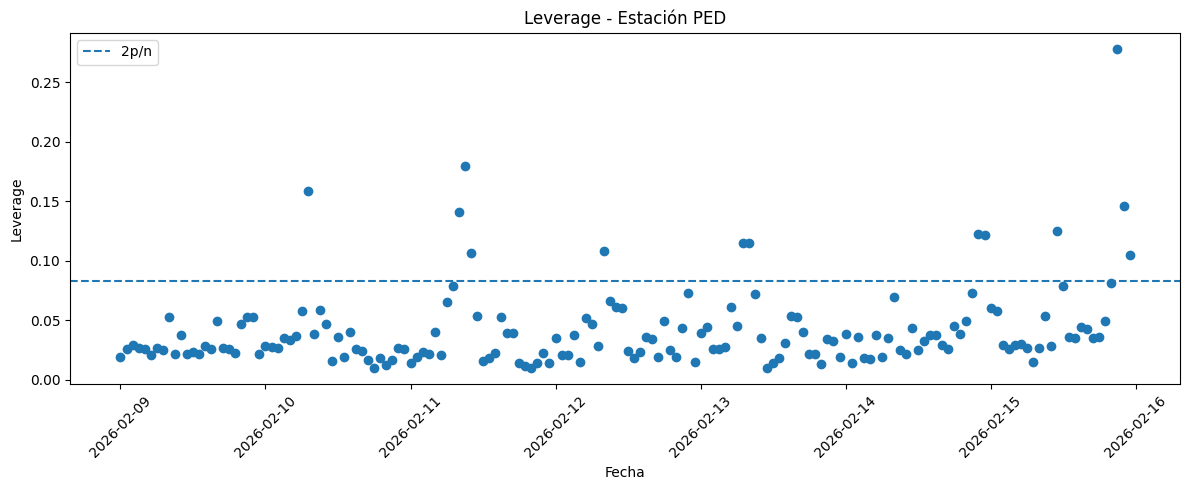

In [42]:
plt.figure(figsize=(12, 5))

plt.scatter(semana["date"], semana["leverage"])

plt.axhline(
    2 * p / len(semana),
    linestyle="--",
    label="2p/n"
)

plt.xlabel("Fecha")
plt.ylabel("Leverage")
plt.title("Leverage - Estación PED")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Leverage de todas las observaciones sin construir H

In [43]:
datos_lev = tabla[["date", "id_station"] + gases].dropna().copy()

X_all = sm.add_constant(datos_lev[gases]).to_numpy()

XtX_inv = np.linalg.pinv(X_all.T @ X_all)

leverage_all = np.einsum(
    "ij,jk,ik->i",
    X_all,
    XtX_inv,
    X_all
)

datos_lev["leverage"] = leverage_all

top10_leverage = datos_lev.nlargest(10, "leverage")

display(
    top10_leverage[
        ["date", "id_station", "leverage"]
    ]
)

print("Suma de leverage:", datos_lev["leverage"].sum())
print("p:", X_all.shape[1])

,date,id_station,leverage
21863,2026-02-06 02:00:00,TLI,0.010601
4296,2026-01-08 05:00:00,UAX,0.008227
21888,2026-02-06 03:00:00,TLI,0.007628
21841,2026-02-06 01:00:00,VIF,0.007558
19502,2026-02-02 01:00:00,CUT,0.005038
5585,2026-01-10 07:00:00,UAX,0.005034
19489,2026-02-02 00:00:00,TLA,0.004728
28604,2026-02-18 07:00:00,MER,0.004665
8925,2026-01-15 18:00:00,CUT,0.004546
21838,2026-02-06 01:00:00,TLI,0.004533


Suma de leverage: 7.000000000001391
p: 7


## f) Cook's Distance e influencia

In [44]:
datos_cook = tabla[
    ["date", "id_station", "PM2.5"] + gases
].dropna().copy()

X_cook = sm.add_constant(datos_cook[gases])
y_cook = datos_cook["PM2.5"]

modelo_cook = sm.OLS(y_cook, X_cook).fit()

influencia = modelo_cook.get_influence()

datos_cook["leverage"] = influencia.hat_matrix_diag
datos_cook["cooks_d"] = influencia.cooks_distance[0]

print("Número de observaciones:", len(datos_cook))

Número de observaciones: 32686


### Diez observaciones más influyentes

In [45]:
top10_cook = datos_cook.nlargest(10, "cooks_d")

display(
    top10_cook[
        ["date", "id_station", "PM2.5", "leverage", "cooks_d"]
    ]
)

,date,id_station,PM2.5,leverage,cooks_d
192,2026-01-01 07:00:00,SAC,323.0,0.002685,0.261088
92,2026-01-01 03:00:00,SAC,349.0,0.002230,0.253419
217,2026-01-01 08:00:00,SAC,296.0,0.002592,0.194491
67,2026-01-01 02:00:00,SAC,324.0,0.001858,0.178968
117,2026-01-01 04:00:00,SAC,290.0,0.001584,0.122915
140,2026-01-01 05:00:00,NEZ,255.0,0.001715,0.096208
167,2026-01-01 06:00:00,SAC,182.0,0.003611,0.080198
242,2026-01-01 09:00:00,SAC,305.0,0.000906,0.074228
165,2026-01-01 06:00:00,NEZ,289.0,0.000846,0.069010
42,2026-01-01 01:00:00,SAC,201.0,0.002088,0.061092


### Diez observaciones con mayor leverage

In [46]:
top10_lev = datos_cook.nlargest(10, "leverage")

display(
    top10_lev[
        ["date", "id_station", "PM2.5", "leverage", "cooks_d"]
    ]
)

,date,id_station,PM2.5,leverage,cooks_d
4296,2026-01-08 05:00:00,UAX,25.0,0.018203,0.001314
5585,2026-01-10 07:00:00,UAX,39.0,0.011275,0.005970
7271,2026-01-13 01:00:00,TLA,21.0,0.010669,0.013278
28604,2026-02-18 07:00:00,MER,37.0,0.010544,0.001017
21699,2026-02-05 20:00:00,CCA,34.0,0.010301,0.012050
25350,2026-02-12 03:00:00,UIZ,40.0,0.008585,0.001400
25344,2026-02-12 03:00:00,MER,28.0,0.008299,0.008153
25393,2026-02-12 05:00:00,UAX,31.0,0.008034,0.002061
50587,2026-03-27 05:00:00,UAX,18.0,0.007506,0.000113
22578,2026-02-07 07:00:00,UAX,26.0,0.007272,0.000299


## ¿Son las mismas?

In [47]:
indices_cook = set(top10_cook.index)
indices_lev = set(top10_lev.index)

comunes = indices_cook.intersection(indices_lev)

print("Observaciones en común:", len(comunes))
print("¿Son exactamente los mismos?:", indices_cook == indices_lev)

Observaciones en común: 0
¿Son exactamente los mismos?: False


### Reajuste del modelo sin las 10 observaciones más influyentes

In [48]:
r2_original = modelo_cook.rsquared
r2_adj_original = modelo_cook.rsquared_adj

datos_sin_influyentes = datos_cook.drop(index=top10_cook.index)

X_nuevo = sm.add_constant(datos_sin_influyentes[gases])
y_nuevo = datos_sin_influyentes["PM2.5"]

modelo_nuevo = sm.OLS(y_nuevo, X_nuevo).fit()

comparacion_modelos = pd.DataFrame({
    "Modelo": ["Original", "Sin 10 más influyentes"],
    "R²": [r2_original, modelo_nuevo.rsquared],
    "R² ajustado": [r2_adj_original, modelo_nuevo.rsquared_adj]
})

display(comparacion_modelos)

,Modelo,R²,R² ajustado
0,Original,0.316695,0.316570
1,Sin 10 más influyentes,0.342393,0.342273


In [49]:
comparacion_coef = pd.DataFrame({
    "Modelo original": modelo_cook.params,
    "Sin 10 influyentes": modelo_nuevo.params
})

comparacion_coef["Diferencia"] = (
    comparacion_coef["Sin 10 influyentes"]
    - comparacion_coef["Modelo original"]
)

display(comparacion_coef)

,Modelo original,Sin 10 influyentes,Diferencia
const,1.586491,1.614462,0.027972
CO,11.531709,8.690767,-2.840942
NO,-0.074357,-0.028392,0.045965
NO2,0.200403,0.281031,0.080628
NOX,0.052246,0.020886,-0.031360
O3,0.165720,0.169183,0.003463
SO2,0.355599,0.350826,-0.004773
